In [3]:
import torch 
import torch.nn as nn 
import torch.optim as optim
import torchvision 
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# transforms 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5,))
])

# loading MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.20MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 71.8kB/s]
100%|██████████| 1.65M/1.65M [00:07<00:00, 224kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.42MB/s]


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Linear(200, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        # flatten
        x = x.view(x.size(0), -1)

        # latent representation
        latent = self.encoder(x)

        # reconstruct input
        reconstructed = self.decoder(latent)

        # reshape to original dimensions
        reconstructed = reconstructed.view(x.size(0), 1, 28, 28)
        return reconstructed

In [11]:
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

Epoch [1/20], Average Loss: 0.1385
Epoch [2/20], Average Loss: 0.0641
Epoch [3/20], Average Loss: 0.0502
Epoch [4/20], Average Loss: 0.0440
Epoch [5/20], Average Loss: 0.0407
Epoch [6/20], Average Loss: 0.0384
Epoch [7/20], Average Loss: 0.0365
Epoch [8/20], Average Loss: 0.0351
Epoch [9/20], Average Loss: 0.0341
Epoch [10/20], Average Loss: 0.0332
Epoch [11/20], Average Loss: 0.0325
Epoch [12/20], Average Loss: 0.0316
Epoch [13/20], Average Loss: 0.0313
Epoch [14/20], Average Loss: 0.0307
Epoch [15/20], Average Loss: 0.0302
Epoch [16/20], Average Loss: 0.0298
Epoch [17/20], Average Loss: 0.0294
Epoch [18/20], Average Loss: 0.0291
Epoch [19/20], Average Loss: 0.0288
Epoch [20/20], Average Loss: 0.0285


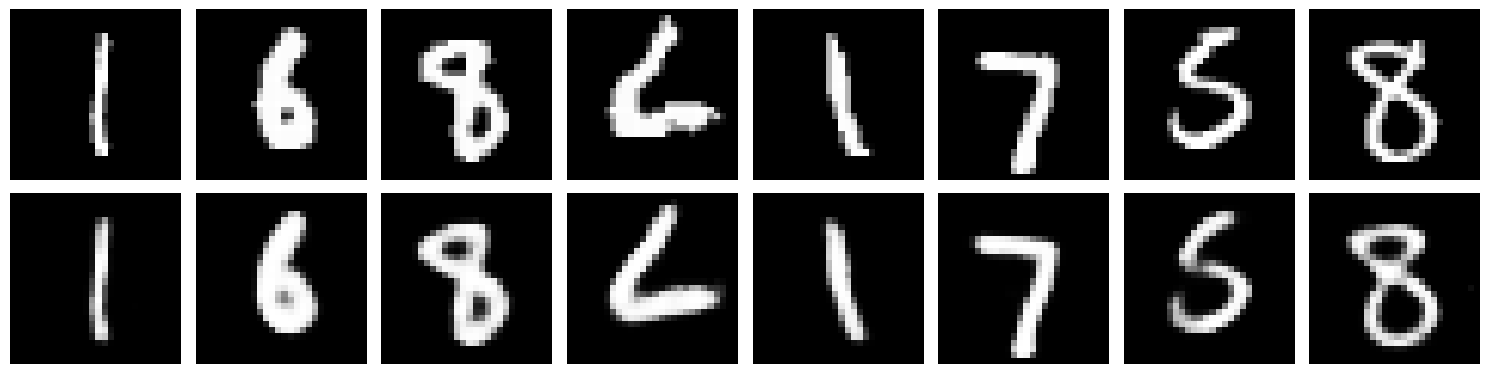

In [17]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, data_loader):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(data_loader))
        images = images.to(device)
        reconstructed = model(images)

        fig, axes = plt.subplots(2, 8, figsize=(15, 4))
        for i in range(8):

            # original
            axes[0,i].imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
            axes[0,i].axis('off')

            # reconstructed 
            axes[1,i].imshow(reconstructed[i].cpu().numpy().squeeze(), cmap='gray')
            axes[1,i].axis('off')

        plt.tight_layout()
        plt.show()

# Visualize results
visualize_reconstruction(model, train_loader)